In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 1634 files belonging to 2 classes.
Found 350 files belonging to 2 classes.
Found 352 files belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 277s 5s/step - accuracy: 0.6481 - loss: 9.2739 - val_accuracy: 0.7857 - val_loss: 0.8889
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 293s 6s/step - accuracy: 0.7907 - loss: 0.6728 - val_accuracy: 0.8429 - val_loss: 0.3703
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.8195 - loss: 0.4076 - val_accuracy: 0.8571 - val_loss: 0.3330
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 296s 6s/step - accuracy: 0.8268 - loss: 0.3920 - val_accuracy: 0.8771 - val_loss: 0.3234
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 293s 6s/step - accuracy: 0.8537 - loss: 0.3626 - val_accuracy: 0.8943 - val_loss: 0.3155
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.8470 - loss: 0.3523 - val_accuracy: 0.8714 - val_loss: 0.3340
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 292s 6s/step - accuracy: 0.8409 - loss: 0.3448 - val_accuracy: 0.8971 - val_loss: 0.2934
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 292s 6s/step - accuracy: 0.8574 - loss: 0.3489 - val_accuracy: 0.9114 - v

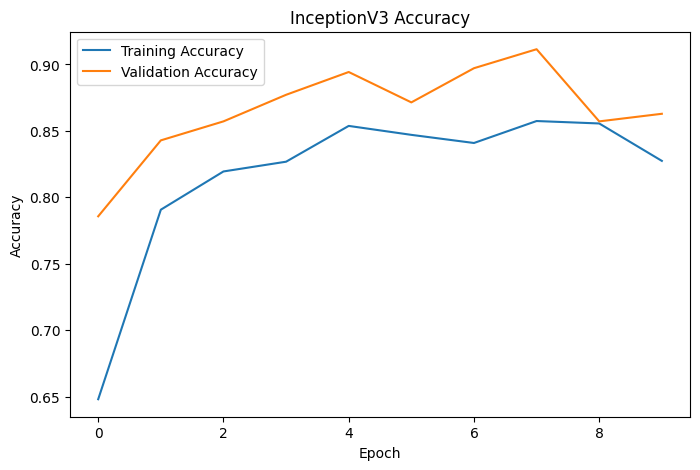

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================================
# DATASET PATH
# =====================================

DATASET_PATH = "/content/drive/MyDrive/preprocessed_data_pad"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =====================================
# LOAD DATASET
# =====================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =====================================
# OPTIMIZE DATA LOADING
# =====================================

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# =====================================
# LOAD INCEPTIONV3 (GOOGLENET FAMILY)
# =====================================

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# =====================================
# BUILD MODEL
# =====================================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

# =====================================
# COMPILE MODEL
# =====================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =====================================
# MODEL SUMMARY
# =====================================

model.summary()

# =====================================
# TRAIN MODEL
# =====================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================
# EVALUATE MODEL
# =====================================

test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(f"Test Accuracy: {test_accuracy:.4f}")

# =====================================
# SAVE MODEL
# =====================================

model.save(
    "/content/drive/MyDrive/inceptionv3_cataract.keras"
)

# =====================================
# PLOT RESULTS
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("InceptionV3 Accuracy")

plt.legend()

plt.show()